### Campos del Recurso y Clasificación Estadística

Esta tabla resume la descripción de cada variable y su clasificación estadística para el análisis.

| Variable | Descripción | Tipo Estadístico | Nivel |
| :--- | :--- | :--- | :--- |
| **long** | Longitud geográfica (X coordinate). | Cuantitativa | Continua |
| **lat** | Latitud geográfica (Y coordinate). | Cuantitativa | Continua |
| **nro_registro** | Número de registro único del árbol. | Cualitativo | Nominal |
| **tipo_activ** | Tipo de actividad o clasificación del árbol. | Cualitativo | Nominal |
| **comuna** | Número de la comuna. | Cualitativo | Nominal |
| **manzana** | Identificador de la manzana. | Cualitativo | Nominal |
| **calle_nombre** | Nombre de la calle. | Cualitativo | Nominal |
| **calle_altura** | Altura de la calle (numérico). | Cuantitativo | Discreto |
| **calle_chapa** | Número de chapa de la calle más cercano. | Cuantitativo | Discreto |
| **direccion_normalizada** | Dirección normalizada. | Cualitativo | Nominal |
| **ubicacion** | Información adicional sobre la ubicación. | Cualitativo | Nominal |
| **nombre_cientifico** | Nombre científico de la especie. | Cualitativo | Nominal |
| **ancho_acera** | Ancho de la acera, en metros. | Cuantitativo | Continuo |
| **estado_plantera** | Estado de la plantación. | Cualitativo | Nominal |
| **ubicacion_plantera** | Condición de la ubicación de la plantación. | Cualitativo | Nominal |
| **nivel_plantera** | Nivel de la plantación respecto al suelo. | Cualitativo | Nominal |
| **diametro_altura_pecho** | Diámetro del árbol a la altura del pecho, en centímetros. | Cuantitativo | Continuo |
| **altura_arbol** | Altura del árbol en metros. | Cuantitativo | Continuo |


In [14]:

from wget import download
from os import path 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy import stats
from scipy.stats import levene, shapiro, chi2_contingency
from itertools import combinations

#abrimos el archivo de base de datos
if not path.exists("arbolado-publico-lineal-2017-2018.csv"):
  download("https://cdn.buenosaires.gob.ar/datosabiertos/datasets/atencion-ciudadana/arbolado-publico-lineal/arbolado-publico-lineal-2017-2018.csv")
else:
  print("El archivo ya existe")

dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")

dataset.info()
#dataset.describe()
dataset["nro_registro"].value_counts()



El archivo ya existe


/tmp/ipykernel_4652/1398108502.py:18: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

nro_registro
26779     1
30887     1
30904     1
31336     1
31337     1
         ..
546140    1
546141    1
546142    1
546143    1
546144    1
Name: count, Length: 370180, dtype: int64

### LIMPIEZA 
**lat y long:** Valores correctos. Nada para limpiar.

**nro_registro:** Vemos que es de tipo object en lugar de entero. Revisamos cuales son los valores no numericos que tiene la columna. Solo hay un tipo de valor no numérico en toda la columna(}). Reemplazamos ese carácter por NaN y luego convertimos toda la columna a un tipo numérico

**tipo_activ:** Decidimos eliminar esta columna. Tenemos la mayoria de las muestras con valores LINEAL y la otra opcion (CALLE) no logramos deducir que significa. No nos aporta nada relevante para las hipotesis que planteamos. 

**manzana:** Segun nuestra busqueda en internet, las letras presentes en los valores de manzana representan la parcela donde se encuentra el arbol. Es por esto que decidimos removerlo, no forma parte de la variable manzana y tampoco es relevante para nuestras hipotesis ponerlo en una columna "parcela". Ademas, habia muchos valores con espacion vacios por lo que los pasamos a NaN.

**calle_nombre:** Eliminamos espacios, puntos, comas y pasamos todo a minusculas para evitar errores.

**calle_altura:** Buscamos si no hay valores decimales, al no encontrar pasamos los datos a Int64.

**calle_chapa:** Buscamos si no hay valores decimales, como hay los dejamos como float.

**direccion_normalizada:** pasamos todo a minuscula y sacamos los espacios en blanco, comas y simbolos. Vemos que los nulos estan cargados como el string "nan" asi que los pasamos a NaN.

**ubicacion:** La variable tiene valores como "exacta" y despues cosas como "la", "ld" "l1". Al no tener mas informacion al respecto decidimos cambiar a una variable dicotomica "ubicacion_exacta" donde sea 1 para todas las muestras que tenian "exacta" y 0 para todo el resto.

**nombre_cientifico:** pasamos todo a minuscula, y cambiamos "no identificado" por nulos.

**ancho_acera:** Eliminamos espacios, simbolos o letras, cambiamos "," por "." y pasamos a float

**estado_plantera:** paso a minusculas y borro las palabras que estan de mas.

**ubicacion_plantera:** paso a minusculas, agrego las letras que faltan y paso "nan" a nulos. Hay valores que pertenecen a las variables "estado_plantera" y "nivel_plantera", entonces en caso que tengan nulo en estas variables pasamos el valor y en "ubicacion_plantera" ponemos nulos."Cantero grande" no es un valor valido para la ubicacion y tampoco tiene relacion con otras variables, por lo tanto lo eliminamos.

**nivel_plantera:** paso a minusculas, elimino espacios y agrupo valores como EL,elevadas,elevado,... por elevada. cambio los strings "nan" y "obs" por NaN de pandas. Hay valores que pertenecen a la variable "ubicacion_plantera", entonces en caso que tengan nulo en esta variable pasamos el valor y en "nivel_plantera" ponemos nulos.

**diametro_altura_pecho:** Variable limpia. No modificamos nada.

**altura_arbol:** Variable limpia. No modificamos nada.

In [15]:
copiaDataset= dataset

#-----COLUMNA "NRO_REGISTRO"-----
# Filtrar valores que realmente sean strings
solo_strings = copiaDataset["nro_registro"].apply(lambda x: isinstance(x, str))
# Aplicar .str solo sobre esos valores convertidos explícitamente a string
no_numericos = (
    copiaDataset.loc[solo_strings, "nro_registro"]
    .astype(str)
    .loc[lambda s: ~s.str.isnumeric()]
)
no_numericos.unique()
# Reemplazar los '}' por NaN
copiaDataset["nro_registro"] = copiaDataset["nro_registro"].replace("}", np.nan)
# Convertir todo a numérico (float o int). 
# "errors='coerce'" convierte a NaN cualquier cosa que no sea número.
copiaDataset["nro_registro"] = pd.to_numeric(copiaDataset["nro_registro"], errors='coerce')
# Convertir a entero con soporte para NaN (para evitar el .0)
copiaDataset["nro_registro"] = copiaDataset["nro_registro"].astype("Int64")

#-----COLUMNA "TIPO_ACTIV"
copiaDataset=copiaDataset.drop(columns=["tipo_activ"])

#-----COLUMNA "MANZANA"
copiaDataset["manzana"] = copiaDataset["manzana"].astype(str)
copiaDataset["manzana"] = copiaDataset["manzana"].str.replace(r'[^0-9]', '',  regex=True)
# Cuántos son realmente NaN
print("NaN reales:", copiaDataset["manzana"].isna().sum())
# Cuántos son cadenas vacías o solo espacios
print("Cadenas vacías o espacios:", (copiaDataset["manzana"].str.strip() == "").sum())
# Reemplazar espacios vacíos por NaN
copiaDataset["manzana"] = copiaDataset["manzana"].replace(r"^\s*$", pd.NA, regex=True)
#los pasamos a valores numericos en lugar de tipo object
copiaDataset["manzana"] = pd.to_numeric(copiaDataset["manzana"], errors="coerce").astype("Int64")

#-----COLUMNA "CALLE_NOMBRE"
copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].astype(str).str.strip().str.lower()
copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].str.replace(r'[^a-z ]', '',  regex=True)

#-----COLUMNA "CALLE_ALTURA"
copiaDataset["calle_altura"] = pd.to_numeric(copiaDataset["calle_altura"], errors='coerce')#convierto la col en numerica, todo en float y si no NaN
(copiaDataset["calle_altura"] % 1 != 0).any()#veo si hay valores decimales
copiaDataset["calle_altura"] = copiaDataset["calle_altura"].astype(float).astype("Int64") #como no hay pasamos a Int64

#-----COLUMNA "CALLE_CHAPA"
copiaDataset["calle_chapa"] = pd.to_numeric(copiaDataset["calle_chapa"], errors='coerce')#convierto la col en numerica, todo en float y si no NaN
(copiaDataset["calle_chapa"] % 1 != 0).any()#veo si hay valores decimales y si hay, lo dejo como float

#-----COLUMNA "DIRECCION_NORMALIZADA"
copiaDataset["direccion_normalizada"] = (copiaDataset["direccion_normalizada"].astype(str).str.strip().str.lower())
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r',', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'[^a-z0-9áéíóúñ ]', '', regex=True)
copiaDataset["direccion_normalizada"].value_counts() #aca vemos que hay un monton de nulos cargados con el string "nan"
copiaDataset["direccion_normalizada"].isna().sum() #y que no hay nulos verdaderos
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].replace("nan", np.nan) #los pasamos a NaN

#-----COLUMNA "UBICACION"
copiaDataset["ubicacion"] = copiaDataset["ubicacion"].astype(str).str.strip().str.lower()
# Crear variable dicotómica
copiaDataset["ubicacion_exacta"] = (copiaDataset["ubicacion"] == "exacta").astype(int)
copiaDataset.drop(columns=["ubicacion"], inplace=True)

#-----COLUMNA "NOMBRE_CIENTIFICO"
copiaDataset["nombre_cientifico"] = copiaDataset["nombre_cientifico"].astype(str).str.strip().str.lower()
copiaDataset["nombre_cientifico"] = copiaDataset ["nombre_cientifico"].replace("no identificado", np.nan)

#-----COLUMNA "ANCHO_ACERA"
copiaDataset["ancho_acera"] = (
    copiaDataset["ancho_acera"]
    .str.replace(r"[^0-9,.\-]", "", regex=True)   # quita $, m, espacios, letras, etc.
    .str.replace(",", ".", regex=False)           # reemplaza coma por punto decimal
    .str.strip()                                  # quita espacios
)
copiaDataset["ancho_acera"] = pd.to_numeric(copiaDataset["ancho_acera"], errors="coerce")

#-----COLUMNA "ESTADO_PLANTERA"
copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].astype(str).str.strip().str.lower()
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('cantero ', '', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('ocupado', 'ocupada', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace("parc.","parcialmente", regex=False)
copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].str.replace(r'\s+', ' ', regex=True)

#-----COLUMNA "UBICACION_PLANTERA"
copiaDataset["ubicacion_plantera"] = copiaDataset["ubicacion_plantera"].astype(str).str.strip().str.lower()
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"^ochva$", 'ochava', regex=True) #indica inicio y fin de cadena, para que no modifique cuando contiene la palabra
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"^o$", 'ochava', regex=True)
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"^och$", 'ochava', regex=True)
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"fuera línea", "fuera de línea", regex=True)
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].replace(["ochava/fuera de línea", "fuera de línea/ochava", "fuera de línea, ochava"], "fuera de línea,ochava")
copiaDataset = copiaDataset[copiaDataset["ubicacion_plantera"] != "cantero grande"]
copiaDataset["ubicacion_plantera"]=copiaDataset["ubicacion_plantera"].replace("nan", np.nan)
#Máscaras según las categorías que corresponden a otras variables
mask_estado = copiaDataset["ubicacion_plantera"].isin(["ocupada", "subocupada", "sobreocupada"])
mask_nivel = copiaDataset["ubicacion_plantera"].isin(["elevada","fuera nivel"])
#Si el estado está nulo y ubicacion_plantera tiene esos valores, los pasamos
copiaDataset.loc[mask_estado & copiaDataset["estado_plantera"].isna(), "estado_plantera"] = \
    copiaDataset.loc[mask_estado & copiaDataset["estado_plantera"].isna(), "ubicacion_plantera"]
copiaDataset.loc[mask_nivel & copiaDataset["nivel_plantera"].isna(), "nivel_plantera"] = \
    copiaDataset.loc[mask_nivel & copiaDataset["nivel_plantera"].isna(), "ubicacion_plantera"]
#Ponemos NaN en ubicacion_plantera
copiaDataset.loc[mask_estado | mask_nivel, "ubicacion_plantera"] = np.nan

#-----COLUMNA "NIVEL_PLANTERA"
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].astype(str).str.strip().str.lower()
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["elevadas","eleveda","el","elevado"],"elevada")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["bn","bajo bivel","baja nivel","reducida"],"bajo nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["an"],"a nivel")
mask_ubicacion = copiaDataset["nivel_plantera"].isin(["ochava", "regular"])
#Si la ubicacion es nulo y nivel_plantera tiene esos valores, los pasamos
copiaDataset.loc[mask_ubicacion & copiaDataset["ubicacion_plantera"].isna(), "ubicacion_plantera"] = \
    copiaDataset.loc[mask_ubicacion & copiaDataset["ubicacion_plantera"].isna(), "nivel_plantera"]
#Ponemos NaN en nivel_plantera
copiaDataset.loc[mask_ubicacion, "nivel_plantera"] = np.nan
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["nan","obs: no tiene plantera definida"],np.nan)

NaN reales: 0
Cadenas vacías o espacios: 146623


### Análisis Univariado

#### Hipotesis 1
- La densidad de árboles por comuna es uniforme.

/tmp/ipykernel_4652/728624888.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


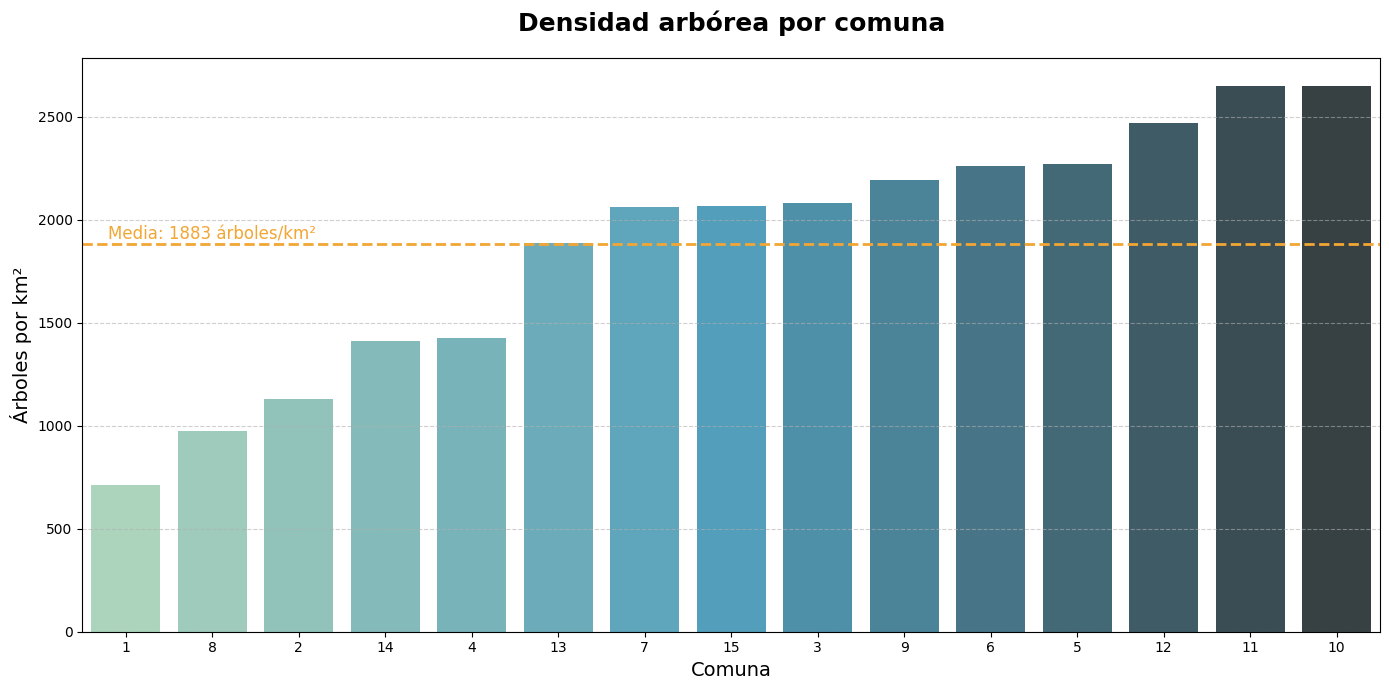

In [31]:
datasetH1 = copiaDataset[["comuna"]].copy()

superficies = {     #en km²
    1: 17.9,  2: 6.3,  3: 6.4,  4: 22.7,  5: 6.7,
    6: 6.9,  7: 12.4, 8: 22.5, 9: 16.6, 10: 12.6,
    11: 14.1, 12: 15.7, 13: 15.0, 14: 15.9, 15: 14.3
}

# Cuento cantidad de arboles por comuna
arboles_por_comuna = datasetH1.groupby("comuna").size().reset_index(name="cantidad_arboles")
# Agrego la superficie de cada comuna
arboles_por_comuna["superficie"] = arboles_por_comuna["comuna"].map(superficies)
# Calculo densidad de arboles por km²
arboles_por_comuna["densidad_arboles"] = arboles_por_comuna["cantidad_arboles"] / arboles_por_comuna["superficie"]

# Calculo la media
densidad_media = arboles_por_comuna["densidad_arboles"].mean()

arboles_ordenados = arboles_por_comuna.sort_values( by="densidad_arboles", ascending=True ) 

plt.figure(figsize=(14, 7))
sns.barplot(
    x="comuna",
    y="densidad_arboles",
    data=arboles_ordenados,
    palette="GnBu_d", # Paleta
    order=arboles_ordenados["comuna"].tolist() 
)

# Agrega la media como linea de referencia para evaluar la uniformidad
plt.axhline(densidad_media, color="#F2A634", linestyle="--", linewidth=2)

plt.text(x= - 0.2, 
y=densidad_media + 20, 
s=f'Media: {densidad_media:.0f} árboles/km²', 
color='#F2A634', # Color del texto (coincide con la linea) 
fontsize=12, # Tamaño de la letra 
ha='left' )

# Personalización del grafico
plt.title("Densidad arbórea por comuna", fontsize=18, pad=20, fontweight="bold")
plt.xlabel("Comuna", fontsize=14)
plt.ylabel("Árboles por km²", fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Como se puede observar, algunas comunas tienen una cantidad de árboles significativamente mayor respecto a otras.
Esto indica una distribución desigual del arbolado urbano.

**Se rechaza la hipotesis planteada.**

### Hipotesis 2
- El 80% de los árboles tienen una altura menor 12 metros.

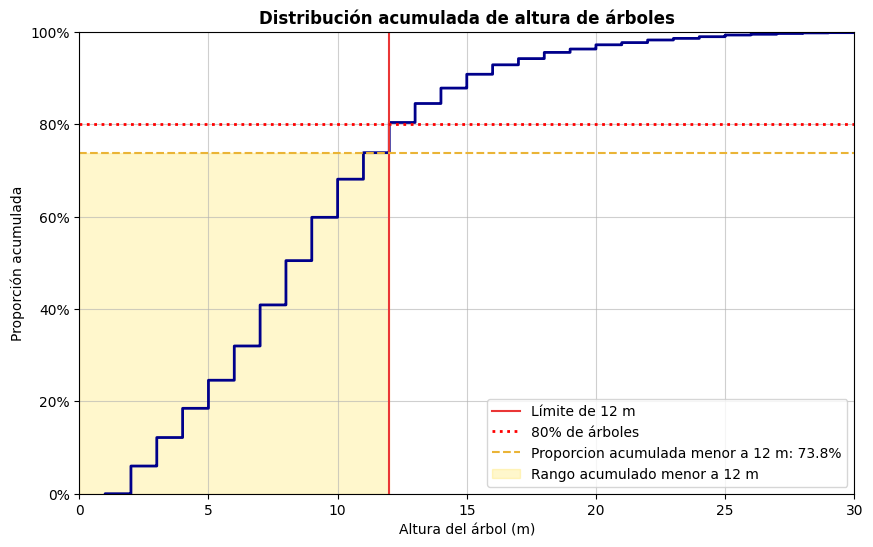

In [32]:
limite = 12
proporcion_hipotesis = 0.80

datasetH2 = copiaDataset[["altura_arbol"]].copy()

# Calculo del percentil 80
altura_p80 = np.percentile(copiaDataset["altura_arbol"].dropna(), 80)

# Calculo de la proporcion acumulada en el limite de 12 m
proporcion_12m_real = (copiaDataset["altura_arbol"].dropna() < limite).mean()  

plt.figure(figsize=(10, 6))

# crear el Grafico de Distribución Acumulada (CDF)
sns.ecdfplot(data=copiaDataset, x="altura_arbol", color="darkblue", linewidth=2)

# Marcar los Límites de la Hipótesis (Eje X, 12 mt)
plt.axvline(x=limite, color="#EA3636", linestyle="-", linewidth=1.5, label=f"Límite de {limite} m")

plt.axhline(proporcion_hipotesis, color="red", linestyle=":", linewidth=2,
            label=f"{proporcion_hipotesis:.0%} de árboles")
plt.axhline(proporcion_12m_real, color="#EAB436", linestyle="--", linewidth=1.5, 
            label=f'Proporcion acumulada menor a {limite} m: {proporcion_12m_real:.1%}')


# marca los porcentaje en eje Y
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))  # "1" indica que el máximo es 1.0 (100%)

# Sombrear SOLO hasta el percentil 80 
plt.axvspan(
    xmin=0,
    xmax=limite,
    ymin=0,
    ymax=proporcion_12m_real,
    color="gold",
    alpha=0.20,
    label="Rango acumulado menor a 12 m"
)
#  Ajustar eje X para evitar demasiado espacio
plt.xlim(0, max(30, altura_p80 + 5))
# Etiquetas y título
plt.title("Distribución acumulada de altura de árboles", fontsize=12, fontweight="bold")
plt.xlabel("Altura del árbol (m)")
plt.ylabel("Proporción acumulada")
plt.legend(loc="lower right")
plt.grid(True, linestyle="-", alpha=0.6)
plt.show()

 Se concluye que la proporción de árboles con altura menor a $12$ metros no es del $80\%$, sino que es significativamente menor, cercana al $73.8\%$
 
**Por lo tanto, se rechaza la hipótesis.**

### Hipotesis 3
- La mediana del ancho de las aceras disponibles para el arbolado urbano en la Ciudad de Buenos Aires es superior a 2.5 metros.

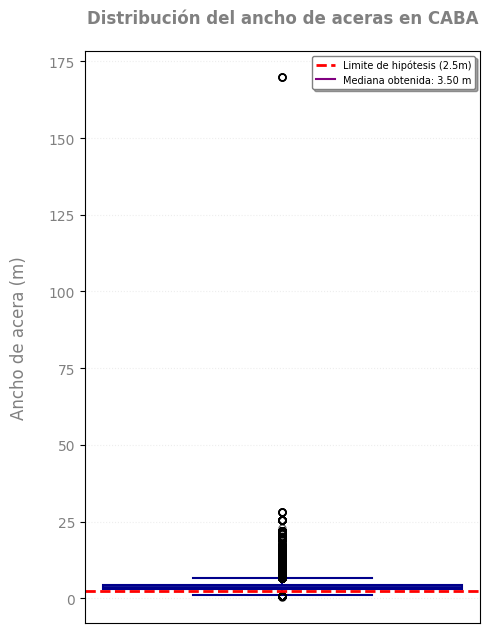

In [33]:
datasetH3 = copiaDataset[["ancho_acera"]].copy()

datasetH3["hipotesis_menor_2_5"] = datasetH3["ancho_acera"] < 2.5

# Cantidad de aceras que cumplen la hipótesis
cantidad = datasetH3["hipotesis_menor_2_5"].sum()

# Calcular la mediana
mediana = datasetH3["ancho_acera"].median()

#Realizamos el Box Plot
#Configuración del gráfico
plt.figure(figsize=(5, 7)) 

ax = sns.boxplot(y=datasetH3['ancho_acera'], 
                 width=0.4,
                 color='lightblue', 
                 medianprops={'color': 'darkblue', 'linewidth': 2}, # Mediana en azul oscuro y mas gruesa
                 boxprops={'edgecolor': 'darkblue', 'linewidth': 1.5}, # Borde de la caja
                 whiskerprops={'color': 'darkblue', 'linewidth': 1.5}, # Bigotes
                 capprops={'color': 'darkblue', 'linewidth': 1.5}, # Tapas de los bigotes
                 flierprops={'marker': 'o', 'markerfacecolor': 'None', 'markeredgecolor': 'black', 'markersize': 5, 'alpha': 0.6} # Outliers
                )

#Añadir la línea de la Hipótesis (2.5m) 
plt.axhline(y=2.5, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label="Limite de hipótesis (2.5m)") # Label 1 para la leyenda

# --- 4. Añadir la Mediana a la LEYENDA (¡Nuevo método!) ---
# Creamos un plot vacío (invisible) solo para tener su etiqueta en la leyenda.
# Usamos ' ' como estilo para que no dibuje nada.
# Ya NO usamos plt.text()
plt.plot([], [], 'purple', label=f'Mediana obtenida: {mediana:.2f} m') # Label 2 para la leyenda

# --- 5. Títulos y etiquetas mejorados ---
ax.set_title("Distribución del ancho de aceras en CABA", 
             fontsize=12, 
             fontweight='bold', 
             color='gray',
             pad=20) # Espaciado del título

ax.set_ylabel("Ancho de acera (m)", 
              fontsize=12, 
              color='gray',
              labelpad=15) # Espaciado de la etiqueta Y

# --- 6. Añadir Leyenda ---
# Ahora la leyenda mostrará AMBOS labels que definimos
plt.legend(fontsize=7, loc='upper right', frameon=True, edgecolor='gray', shadow=True)

# --- 7. Mejoras de la grilla y ticks ---
plt.grid(True, linestyle=':', alpha=0.4, color='lightgray') # Grilla más sutil
plt.yticks(fontsize=10, color='gray') # Estilo de los números del eje Y
plt.xticks([]) # Oculta los ticks del eje X

# --- 8. Mostrar el gráfico ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el título no se corte
plt.show()

A partir de este grafico vemos que hay muchisimos outliers en la variable ancho_acera. Lo que sucede es que hay valores tan grandes que el eje Y se ve forzado a escalar para incluirlos. Esto comprime la mayor parte de los datos en una línea delgada en la parte inferior, haciendo imposible ver la distribución real. Vamos a analizar que pasa con estos valores extremos:

In [28]:
print(datasetH3["ancho_acera"].describe())

# Esto calcula el umbral matematico que Seaborn usa para decidir que es un outlier
Q1 = datasetH3["ancho_acera"].quantile(0.25)
Q3 = datasetH3["ancho_acera"].quantile(0.75)
IQR = Q3 - Q1

# El limite superior estandar es Q3 + 1.5 * IQR
limite_superior = Q3 + (1.5 * IQR)

# Contamos cuantos hay por encima de ese limite
outliers = datasetH3[datasetH3["ancho_acera"] > limite_superior]

#Informacion sobre outliers
print(f"Total de registros: {len(datasetH3)}")
print(f"Cantidad de outliers: {len(outliers)}")
print(f"Porcentaje de outliers: {(len(outliers) / len(datasetH3)) * 100:.2f}%")

# Vemos los valores mas grandes
print(outliers.nlargest(10, "ancho_acera"))

count    367037.000000
mean          3.788785
std           1.518701
min           0.400000
25%           3.000000
50%           3.500000
75%           4.400000
max         170.000000
Name: ancho_acera, dtype: float64
Total de registros: 370167
Cantidad de outliers: 8780
Porcentaje de outliers: 2.37%
        ancho_acera  hipotesis_menor_2_5
230621        170.0                False
230622        170.0                False
231585        170.0                False
231652        170.0                False
233885        170.0                False
233886        170.0                False
233893        170.0                False
93204          28.0                False
319583         28.0                False
319662         28.0                False


Vemos que el maximo es de 170 metros, lo cual es imposible. Decidimos corregir el dato suponiendo que fue un error de tipeo.

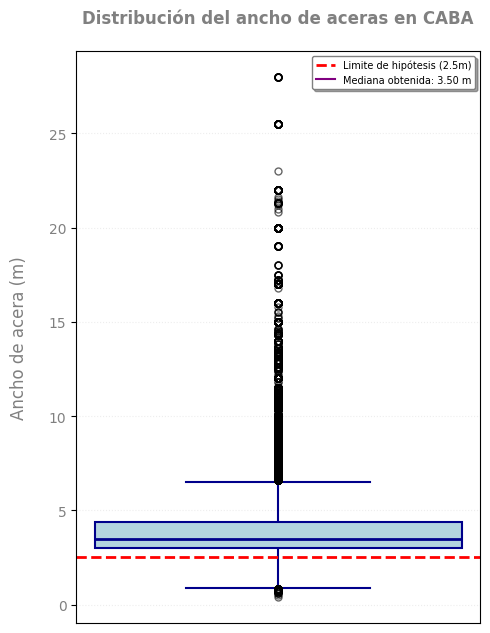

In [34]:
datasetH3.loc[datasetH3["ancho_acera"] == 170.0, "ancho_acera"] = 1.7

mediana = datasetH3["ancho_acera"].median()

#Realizamos el Box Plot
plt.figure(figsize=(5, 7)) 

ax = sns.boxplot(y=datasetH3['ancho_acera'], 
                 width=0.4,
                 color='lightblue', 
                 medianprops={'color': 'darkblue', 'linewidth': 2}, # Mediana en azul oscuro y más gruesa
                 boxprops={'edgecolor': 'darkblue', 'linewidth': 1.5}, # Borde de la caja
                 whiskerprops={'color': 'darkblue', 'linewidth': 1.5}, # Bigotes
                 capprops={'color': 'darkblue', 'linewidth': 1.5}, # Tapas de los bigotes
                 flierprops={'marker': 'o', 'markerfacecolor': 'None', 'markeredgecolor': 'black', 'markersize': 5, 'alpha': 0.6} # Outliers
                )

#Añade la linea de la Hipotesis (2.5m)
plt.axhline(y=2.5, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label="Limite de hipótesis (2.5m)") 


plt.plot([], [], 'purple', label=f"Mediana obtenida: {mediana:.2f} m") 

# Titulos y etiquetas
ax.set_title("Distribución del ancho de aceras en CABA", 
             fontsize=12, 
             fontweight='bold', 
             color='gray',
             pad=20) # Espaciado del título

ax.set_ylabel("Ancho de acera (m)", 
              fontsize=12, 
              color='gray',
              labelpad=15) # Espaciado de la etiqueta Y


plt.legend(fontsize=7, loc='upper right', frameon=True, edgecolor='gray', shadow=True)

plt.grid(True, linestyle=':', alpha=0.4, color='lightgray') # Grilla más sutil
plt.yticks(fontsize=10, color='gray') # Estilo de los números del eje Y
plt.xticks([]) # Oculta los ticks del eje X
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el título no se corte
plt.show()

Ahora podemos ver mejor la distribucion. Si bien podemos ver en que valor se encuentra la mediana respecto al 2.5m de nuestra hipotesis, creemos necesario continuar la limpieza de los outliers.
Buscamos en el dataset en que ubicacion se encuentran los arboles (lat y long) que representan los outliers mas extremos y los buscamos en Google Maps para ver si realmente tenian estos valores de ancho de acera o estaban mal cargados. Finalmente vemos que era asi, ya que las veredas reales no tienen ese ancho; asi que lo corregimos igual que con el 170.0.

In [30]:
resultados_28m = copiaDataset.loc[copiaDataset["ancho_acera"] == 28.0, ["ancho_acera", "long", "lat"]]
resultados_25m = copiaDataset.loc[copiaDataset["ancho_acera"] == 25.5, ["ancho_acera", "long", "lat"]]

print("Aceras con ancho de 28.0 metros:")
print(resultados_28m)
print("Aceras con ancho de 25.5 metros:")
print(resultados_25m)

#Correccion
datasetH3.loc[datasetH3["ancho_acera"] == 28.0, "ancho_acera"] = 2.8
datasetH3.loc[datasetH3["ancho_acera"] == 25.5, "ancho_acera"] = 2.55

Aceras con ancho de 28.0 metros:
        ancho_acera       long        lat
93204          28.0 -58.461803 -34.634639
319583         28.0 -58.402248 -34.581743
319662         28.0 -58.402248 -34.581743
319664         28.0 -58.402248 -34.581743
319665         28.0 -58.402616 -34.581625
319667         28.0 -58.402897 -34.581534
319714         28.0 -58.402248 -34.581743
319715         28.0 -58.402897 -34.581534
319716         28.0 -58.402616 -34.581625
319717         28.0 -58.402248 -34.581743
Aceras con ancho de 25.5 metros:
        ancho_acera       long        lat
275129         25.5 -58.508502 -34.575468
275130         25.5 -58.508502 -34.575468
275131         25.5 -58.508502 -34.575468
275132         25.5 -58.508502 -34.575468
275133         25.5 -58.508502 -34.575468
275134         25.5 -58.508502 -34.575468
275135         25.5 -58.508502 -34.575468
275136         25.5 -58.508502 -34.575468
275137         25.5 -58.508502 -34.575468
275138         25.5 -58.508502 -34.575468
275139    

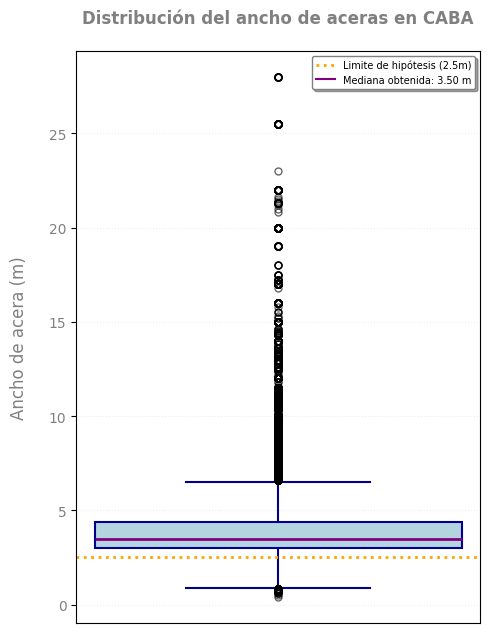

In [35]:
plt.figure(figsize=(5, 7)) 

ax = sns.boxplot(y=datasetH3['ancho_acera'], 
                 width=0.4, 
                 color='lightblue', 
                 medianprops={'color': 'purple', 'linewidth': 2}, # Mediana en azul oscuro y más gruesa
                 boxprops={'edgecolor': 'darkblue', 'linewidth': 1.5}, # Borde de la caja
                 whiskerprops={'color': 'darkblue', 'linewidth': 1.5}, # Bigotes
                 capprops={'color': 'darkblue', 'linewidth': 1.5}, # Tapas de los bigotes
                 flierprops={'marker': 'o', 'markerfacecolor': 'None', 'markeredgecolor': 'black', 'markersize': 5, 'alpha': 0.6} # Outliers
                )

plt.axhline(y=2.5, 
            color='orange', 
            linestyle=':', 
            linewidth=2, 
            label="Limite de hipótesis (2.5m)") 

plt.plot([], [], 'purple', label=f'Mediana obtenida: {mediana:.2f} m') 

# --- 5. Títulos y etiquetas mejorados ---
ax.set_title("Distribución del ancho de aceras en CABA", 
             fontsize=12, 
             fontweight='bold', 
             color='gray',
             pad=20) # Espaciado del título

ax.set_ylabel("Ancho de acera (m)", 
              fontsize=12, 
              color='gray',
              labelpad=15) # Espaciado de la etiqueta Y

plt.legend(fontsize=7, loc='upper right', frameon=True, edgecolor='gray', shadow=True)

plt.grid(True, linestyle=':', alpha=0.4, color='lightgray') 
plt.yticks(fontsize=10, color='gray') 
plt.xticks([]) 
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el título no se corte
plt.show()

Podemos ver que la mediana se encuentra por encima a la planteada en nuestra hipotesis.

**La hipotesis se cumple.**

### ANALISIS BIVARIADO

### Hipotesis 4
- Existe una asociacion entre la comuna donde se encuentra el arbol y el estado de la plantera.


--- Porcentaje de Buen y Mal Estado de Planteras por Comuna ---
buen_estado  Mal Estado (%)  Buen Estado (%)  Total planteras
comuna                                                       
1                      5.73            94.27            12723
2                      8.25            91.75             7115
3                      3.48            96.52            13320
4                      6.66            93.34            32343
5                      9.06            90.94            15224
6                      8.61            91.39            15591
7                      9.60            90.40            25608
8                      9.35            90.65            21968
9                     11.83            88.17            36405
10                    14.32            85.68            33421
11                    14.05            85.95            37340
12                    12.31            87.69            38818
13                    10.67            89.33            28287
14    

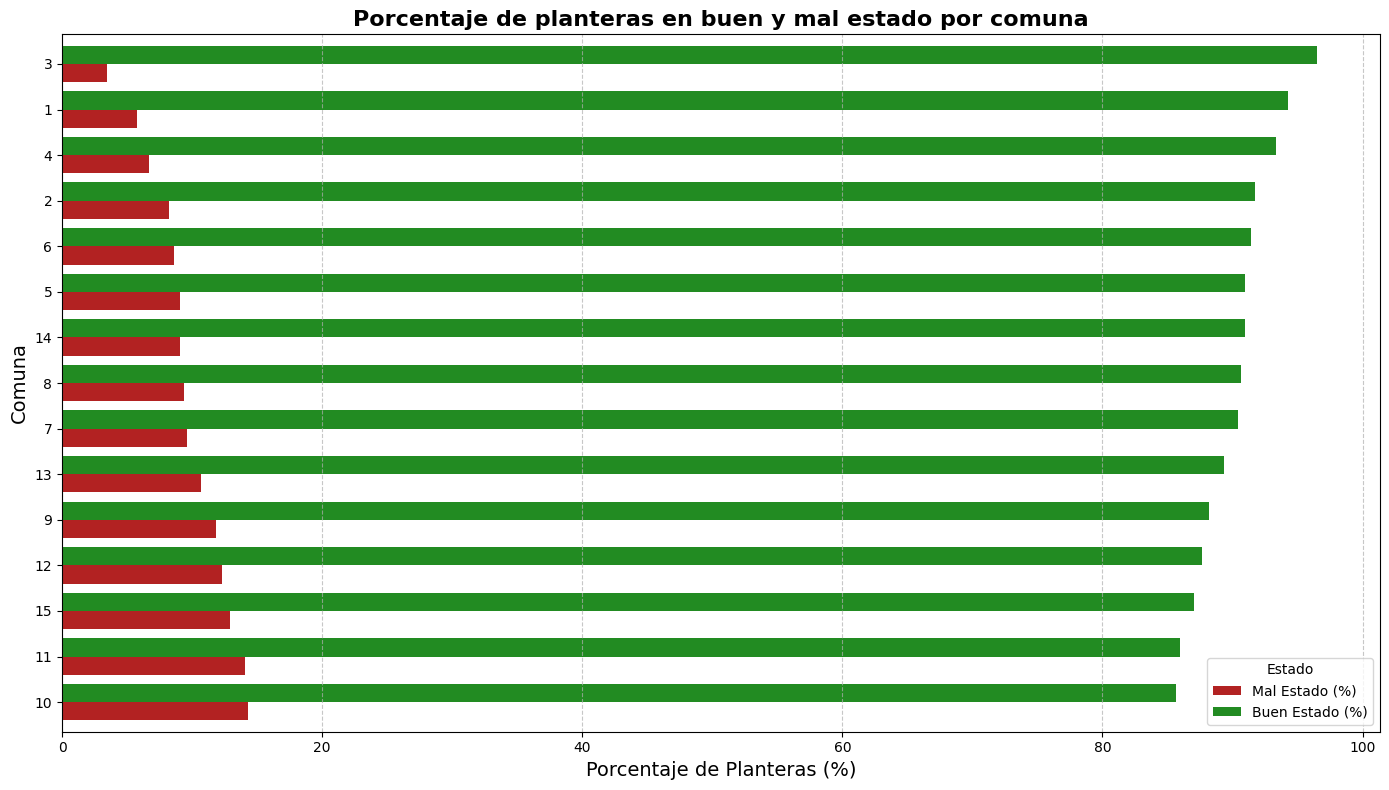

In [ ]:
datasetH4= copiaDataset[["comuna","estado_plantera"]].copy()
datasetH4["buen_estado"] = 0

b_estado = (
    (datasetH4["estado_plantera"]=="ocupada") | 
    (datasetH4["estado_plantera"]=="cerrada")
)

datasetH4.loc[b_estado, "buen_estado"] = 1

#Crea grupos de todas las combinaciones posibles de comuna y estado. y cuenta de cada uno
conteo_por_estado = datasetH4.groupby(["comuna", "buen_estado"]).size().reset_index(name="conteo")

# Calcula el total de planteras por cada comuna para el porcentaje
total_por_comuna = datasetH4.groupby("comuna").size().reset_index(name="total_comuna")

#Combina conteo_por_estado y total_por_comuna usando la columna comuna como clave.
resultados = pd.merge(conteo_por_estado, total_por_comuna, on="comuna")
resultados["porcentaje"] = (resultados["conteo"] / resultados["total_comuna"]) * 100

# Transforma la tabla para que los estados (0 y 1) sean columnas
resultados_comuna = resultados.pivot(
    index="comuna", 
    columns="buen_estado", 
    values="porcentaje"
).fillna(0).rename(columns={0: "Mal Estado (%)", 1: "Buen Estado (%)"})

resultados_comuna["Total planteras"] = total_por_comuna.set_index("comuna")["total_comuna"]
# Muestra el resultado final
print("--- Porcentaje de Buen y Mal Estado de Planteras por Comuna ---")
print(resultados_comuna.round(2))

df_grafico = resultados_comuna.drop(columns=["Total planteras"])

# Reordenar las comunas por el porcentaje de Mal Estado
df_grafico = df_grafico.sort_values(by="Mal Estado (%)", ascending=False)

# 2. Configurar el gráfico
plt.figure(figsize=(14, 8))
ax = plt.gca()

df_grafico.plot(
    kind="barh", 
    ax=ax, 
    color={"Buen Estado (%)": "forestgreen", "Mal Estado (%)": "firebrick"},
    width=0.8 # Ancho de las barras
)

plt.title("Porcentaje de planteras en buen y mal estado por comuna", fontsize=16, fontweight="bold")
plt.xlabel("Porcentaje de Planteras (%)", fontsize=14)
plt.ylabel("Comuna", fontsize=14)
plt.legend(title="Estado", loc="lower right", fontsize=10)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

El grafico muestra que no hay relacion significativa entre la comuna y el estado de la plantera ya que la proporcion de planteras en buen y mal estado es similar en todas las comunas.

**Es por esto que, se rechaza la hipotesis planteada.**

### Hipotesis 5
- El promedio de la proporción de Platanus x acerifolia por comuna es similar entre las regiones de la Ciudad de Buenos Aires.

    comuna    region  prop_platanus
0        1   noreste       0.119311
1        2   noreste       0.098384
2        3   sudeste       0.049550
3        4   sudeste       0.070834
4        5   sudeste       0.115738
5        6   sudeste       0.066577
6        7   sudeste       0.070993
7        8  sudoeste       0.043563
8        9  sudoeste       0.072105
9       10  sudoeste       0.076359
10      11  noroeste       0.109588
11      12  noroeste       0.069658
12      13   noreste       0.081062
13      14   noreste       0.153232
14      15  noroeste       0.135262

--- PRUEBA DE LEVENE (Homocedasticidad) ---
Estadístico de Levene: 0.3865
p-value: 0.7650
NO se rechaza la hipótesis nula: LAS VARIANZAS SON IGUALES

--- PRUEBA DE NORMALIDAD (Shapiro-Wilk en residuos) ---
Estadístico de Shapiro-Wilk: 0.9498
p-value: 0.5210
NO se rechaza la hipótesis nula: LOS RESIDUOS SIGUEN DISTRIBUCIÓN NORMAL


/tmp/ipykernel_4652/588026185.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([datos_por_region[region] for region in regiones], labels=regiones)


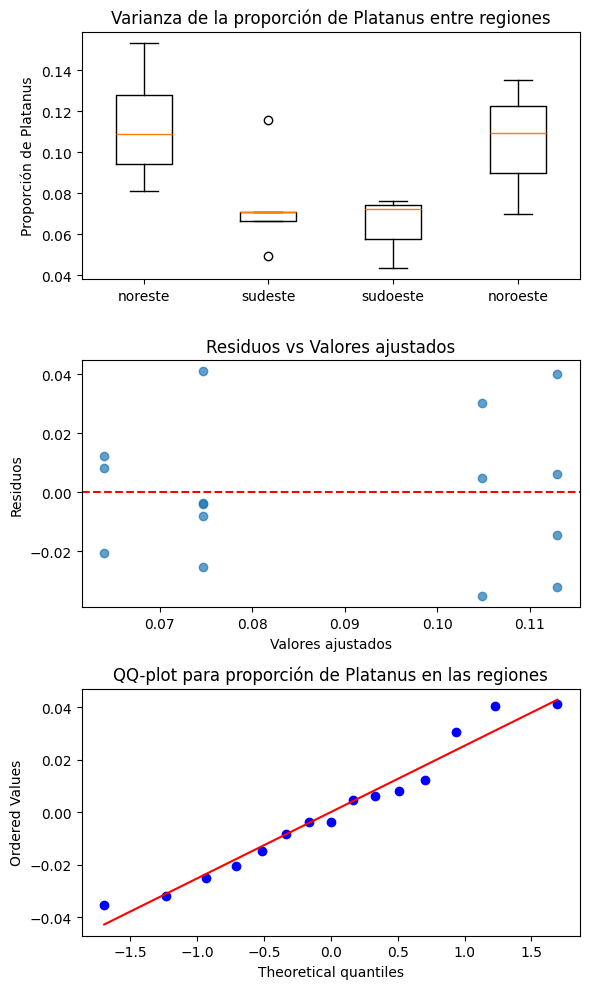

Estadístico F: 2.6831
p-value: 0.0982
0.09820539886557537
Resultado NO significativo: No hay diferencias entre regiones


In [ ]:
#H0:las proporciones de Platanus x acerifolia son iguales en todas las regiones
#H1: existen diferencias en la proporción de Platanus x acerifolia entre las regiones.

datasetH5 = copiaDataset[["comuna","nombre_cientifico"]].copy()

#planteamos cuatro grupos: noreste,sureste,noroeste,sudoeste
mapeo_regiones={
    1 : "noreste",
    2 : "noreste",
    3 : "sudeste",
    4 : "sudeste",
    5 : "sudeste",
    6 : "sudeste",
    7 : "sudeste",
    8 : "sudoeste",
    9 : "sudoeste",
    10 : "sudoeste",
    11 : "noroeste",
    12 : "noroeste",
    13 : "noreste",
    14 : "noreste",
    15 : "noroeste",
}
datasetH5["region"]=datasetH5["comuna"].map(mapeo_regiones)
datasetH5["es_platanus"] = datasetH5["nombre_cientifico"].str.contains("platanus", case =False,na=False)


proporcion = datasetH5.groupby(["comuna", "region"]).agg(
    prop_platanus=("es_platanus", "mean")  # "mean" de booleanos es la proporción
).reset_index()

print(proporcion)

regiones = proporcion['region'].unique()
datos_por_region = {}

for region in regiones:
    datos_por_region[region] = proporcion[proporcion['region'] == region]['prop_platanus'].values

# 2. Verificar HOMOCEDASTICIDAD (igualdad de varianzas) - Test de Levene
print("\n--- PRUEBA DE LEVENE (Homocedasticidad) ---")
levene_stat, levene_p = levene(*datos_por_region.values())
print(f"Estadístico de Levene: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")

if levene_p > 0.05:
    print("NO se rechaza la hipótesis nula: LAS VARIANZAS SON IGUALES")
    homocedasticidad = True
else:
    print("SE RECHAZA la hipótesis nula: LAS VARIANZAS NO SON IGUALES")
    homocedasticidad = False

# 3. Verificar NORMALIDAD - Test de Shapiro-Wilk en los residuos
print("\n--- PRUEBA DE NORMALIDAD (Shapiro-Wilk en residuos) ---")

# Calcular residuos (diferencia entre cada valor y la media de su grupo)
residuos = []
for idx, row in proporcion.iterrows():
    region = row['region']
    media_region = np.mean(datos_por_region[region])
    residuo = row['prop_platanus'] - media_region
    residuos.append(residuo)

residuos = np.array(residuos)

# Test de Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuos)
print(f"Estadístico de Shapiro-Wilk: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("NO se rechaza la hipótesis nula: LOS RESIDUOS SIGUEN DISTRIBUCIÓN NORMAL")
    normalidad = True
else:
    print("SE RECHAZA la hipótesis nula: LOS RESIDUOS NO SIGUEN DISTRIBUCIÓN NORMAL")
    normalidad = False

fig, axes = plt.subplots(3, 1, figsize=(6, 10))

# --- GRÁFICO 1: Boxplot por región (homocedasticidad) ---
axes[0].boxplot([datos_por_region[region] for region in regiones], labels=regiones)
axes[0].set_title('Varianza de la proporción de Platanus entre regiones')
axes[0].set_ylabel('Proporción de Platanus')

# --- GRÁFICO 2: Residuos vs valores ajustados (homocedasticidad) ---
valores_ajustados = [np.mean(datos_por_region[row['region']]) for idx, row in proporcion.iterrows()]
axes[1].scatter(valores_ajustados, residuos, alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuos vs Valores ajustados')
axes[1].set_xlabel('Valores ajustados')
axes[1].set_ylabel('Residuos')

# --- GRÁFICO 3: QQ-plot de residuos (normalidad) ---
stats.probplot(residuos, dist="norm", plot=axes[2])
axes[2].set_title('QQ-plot para proporción de Platanus en las regiones')

plt.tight_layout()
plt.show()

#tanto el p valor del test de levene como de shapiro nos dio >0,05, 
#por lo tanto se cumplen los supuestos de ANOVA y podemos hacer el test parametrico

# ANOVA paramétrico
anova_result = stats.f_oneway(*[datos_por_region[region] for region in regiones])
print(f"Estadístico F: {anova_result.statistic:.4f}")
print(f"p-value: {anova_result.pvalue:.4f}")

print(anova_result.pvalue)





El resultado del test ANOVA nos dice que no es significativo (para un nivel de significancia de 0.05), es decir que las proporciones de Platanus x acerifolia son similares en todas las regiones.

**Sin embargo, viendo el p-valor podemos decir que si aumentamos el nivel de significancia a 0.1 ya pasa a ser significativo y la hipotesis se acepta.**

### MULTIVARIADA

### Hipotesis 6
- El riesgo potencial de daño —definido como la presencia de especies con alto requerimiento de espacio radicular ubicadas en aceras cuyo ancho es inferior al recomendado— varía significativamente entre regiones de comunas.

/tmp/ipykernel_4652/1020525320.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  riesgo_por_region = datasetH.groupby("region")["riesgo_potencial"].mean().sort_values(ascending=False).to_frame()


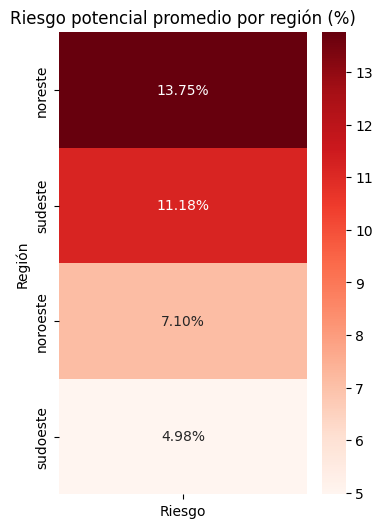

Tabla de contingencia:
 riesgo_potencial      0      1
region                        
noreste           60841   9701
noroeste          98233   7512
sudeste           90676  11410
sudoeste          87226   4568 

Chi2 = 4830.18
p-value = 0.0000
Grados de libertad = 3

Frecuencias esperadas:
 riesgo_potencial             0            1
region                                     
noreste           64216.856154  6325.143846
noroeste          96263.381447  9481.618553
sudeste           92932.465444  9153.534556
sudoeste          83563.296955  8230.703045 

p < 0.05: Rechazamos la hipótesis nula. El riesgo potencial varía significativamente entre regiones.


In [25]:
datasetH = copiaDataset[["nombre_cientifico", "comuna", "ancho_acera"]].copy()

# Diccionario con el ancho mínimo recomendado para cada especie problemática
ancho_minimo = {
    "platanus x acerifolia": 4.0,
    "ficus benjamina": 4.0,
    "tilia x moltkei": 3.8
}

# Crear columna de riesgo potencial: por defecto 0
datasetH["riesgo_potencial"] = 0

especies_conflictivas = list(ancho_minimo.keys())
datasetH['es_especie_conflictiva'] = datasetH['nombre_cientifico'].isin(especies_conflictivas)

# Para cada especie problemática, marcar riesgo = 1 si la acera es más angosta que el mínimo
for especie_conflictiva, ancho_req in ancho_minimo.items():
    condicion = (
        (datasetH["nombre_cientifico"] == especie_conflictiva) &
        (datasetH["ancho_acera"] < ancho_req)
    )
    datasetH.loc[condicion, "riesgo_potencial"] = 1

# ============================================================
# 👉 NUEVO: Mapeo de comunas a regiones
# ============================================================
mapeo_regiones = {
    1: "noreste",
    2: "noreste",
    3: "sudeste",
    4: "sudeste",
    5: "sudeste",
    6: "sudeste",
    7: "sudeste",
    8: "sudoeste",
    9: "sudoeste",
    10: "sudoeste",
    11: "noroeste",
    12: "noroeste",
    13: "noreste",
    14: "noreste",
    15: "noroeste",
}

# Crear nueva variable categórica región
datasetH["region"] = datasetH["comuna"].map(mapeo_regiones)
datasetH["region"] = datasetH["region"].astype("category")
# ============================================================


# ============================================================
# Heatmap según regiones en lugar de comunas
# ============================================================
riesgo_por_region = datasetH.groupby("region")["riesgo_potencial"].mean().sort_values(ascending=False).to_frame()
riesgo_por_region.columns = ["Riesgo"]
riesgo_por_region["Riesgo"] = riesgo_por_region["Riesgo"] * 100
riesgo_por_region["riesgo_texto"] = riesgo_por_region["Riesgo"].map(lambda x: f"{x:.2f}%")

plt.figure(figsize=(4, 6))
sns.heatmap(
    riesgo_por_region[["Riesgo"]],
    annot=riesgo_por_region[["riesgo_texto"]],
    fmt="",
    cmap="Reds"
)
plt.title("Riesgo potencial promedio por región (%)")
plt.xlabel("")
plt.ylabel("Región")
plt.show()
# ============================================================

# 1️⃣ Tabla de contingencia
tabla = pd.crosstab(datasetH["region"], datasetH["riesgo_potencial"])
print("Tabla de contingencia:\n", tabla, "\n")

# 2️⃣ Chi-cuadrado de independencia
chi2, p, dof, expected = stats.chi2_contingency(tabla)
print(f"Chi2 = {chi2:.2f}")
print(f"p-value = {p:.4f}")
print(f"Grados de libertad = {dof}\n")

# 3️⃣ Frecuencias esperadas
expected_df = pd.DataFrame(expected, index=tabla.index, columns=tabla.columns)
print("Frecuencias esperadas:\n", expected_df, "\n")

# 4️⃣ Interpretación automática
alpha = 0.05
if p < alpha:
    print(f"p < {alpha}: Rechazamos la hipótesis nula. El riesgo potencial varía significativamente entre regiones.")
else:
    print(f"p ≥ {alpha}: No podemos rechazar la hipótesis nula. No hay evidencia de diferencias significativas de riesgo entre regiones.")

